In [1]:
from glob import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
err_files = glob('outLogs/eval_model_31801546_*.err')

In [3]:
import pickle

word_list = list(pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )).keys())


In [10]:
rerun = set()
for fn in err_files:
    with open(fn, 'r') as f:
        lines = f.readlines()
        for line in lines:
            line = line.lower()
            if 'error' in line:
                rerun.add(fn)

In [12]:
import pickle
old_rerun = pickle.load(open('rerun_dict_2.pkl', 'rb'))

In [16]:
rerun = list(rerun)
i = 0
rerun_dict = dict()
for r in rerun:
    og_idx = int(r.split('_')[-1][:-4])
    rerun_dict[i] = old_rerun[og_idx]
    i += 1

In [17]:
import pickle
with open('rerun_dict_3.pkl', 'wb') as f:
    pickle.dump(rerun_dict, f)

In [33]:
test_files = glob('binaural_eval/word_task_voice_and_loc_cue_8_01/*.pkl')

In [34]:
result_df = pd.DataFrame()
condition = []
target_loc = []
distractor_loc = []
accuracy = []
acc_error = []
confusions = []
con_error = []
for f in test_files:
    file_dict = pd.read_pickle(f)
    for con in file_dict.keys():
        condition.append(con)
        targ_loc = file_dict[con]['target_loc']
        if targ_loc[0] > 90:
            azim = 360 - targ_loc[0]
        else:
            azim = 0 - targ_loc[0]
        target_loc.append((azim, 0))
        dist_loc = file_dict[con]['distract_loc']
        if dist_loc[0] > 90:
            azim = 360 - dist_loc[0]
        else:
            azim = 0 - dist_loc[0]
        distractor_loc.append((azim, 0))
        accuracy.append(file_dict[con]['results'][0])
        acc_error.append(file_dict[con]['results'][1])
        confusions.append(file_dict[con]['confusions'][0])
        con_error.append(file_dict[con]['confusions'][1])

result_df['condition'] = condition
result_df['target_loc'] = target_loc
result_df['distractor_loc'] = distractor_loc
result_df['accuracy'] = accuracy
result_df['acc_error'] = acc_error
result_df['confusions'] = confusions
result_df['con_error'] = con_error

<AxesSubplot:xlabel='distractor_loc', ylabel='target_loc'>

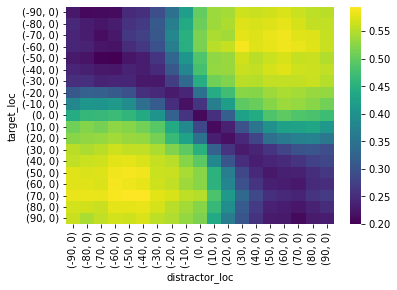

In [35]:
mean_acc = result_df.groupby(['target_loc', 'distractor_loc']).mean()['accuracy']
sns.heatmap(mean_acc.unstack(), cmap='viridis')

<AxesSubplot:xlabel='distractor_loc', ylabel='target_loc'>

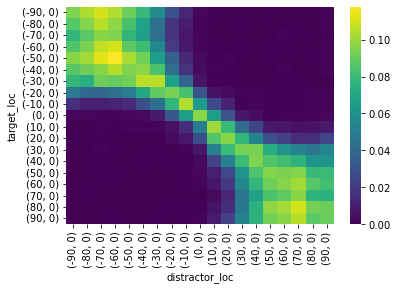

In [36]:
mean_con = result_df.groupby(['target_loc', 'distractor_loc']).mean()['confusions']
sns.heatmap(mean_con.unstack(), cmap='viridis')

In [37]:
same_sex = result_df[(result_df['condition'] == 'm_m') | (result_df['condition'] == 'f_f')]
print(result_df['accuracy'].max())

0.6020278833967047


<AxesSubplot:xlabel='distractor_loc', ylabel='target_loc'>

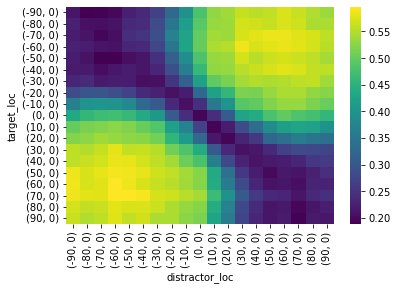

In [38]:
mean_acc = same_sex.groupby(['target_loc', 'distractor_loc']).mean()['accuracy']
sns.heatmap(mean_acc.unstack(), cmap='viridis')

<AxesSubplot:xlabel='distractor_loc', ylabel='target_loc'>

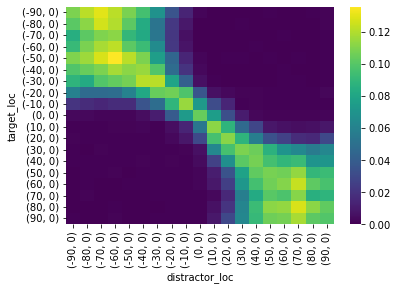

In [39]:
mean_con = same_sex.groupby(['target_loc', 'distractor_loc']).mean()['confusions']
sns.heatmap(mean_con.unstack(), cmap='viridis')

In [40]:
diff_sex = result_df[(result_df['condition'] == 'm_f') | (result_df['condition'] == 'f_m')]

<AxesSubplot:xlabel='distractor_loc', ylabel='target_loc'>

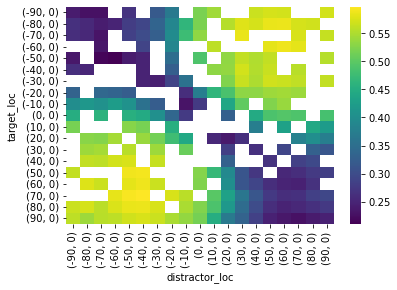

In [86]:
mean_acc = diff_sex.groupby(['target_loc', 'distractor_loc']).mean()['accuracy']
sns.heatmap(mean_acc.unstack(), cmap='viridis')

<AxesSubplot:xlabel='distractor_loc', ylabel='target_loc'>

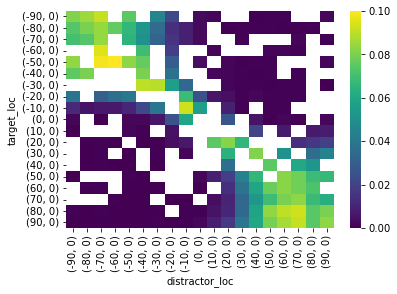

In [87]:
mean_con = diff_sex.groupby(['target_loc', 'distractor_loc']).mean()['confusions']
sns.heatmap(mean_con.unstack(), cmap='viridis')

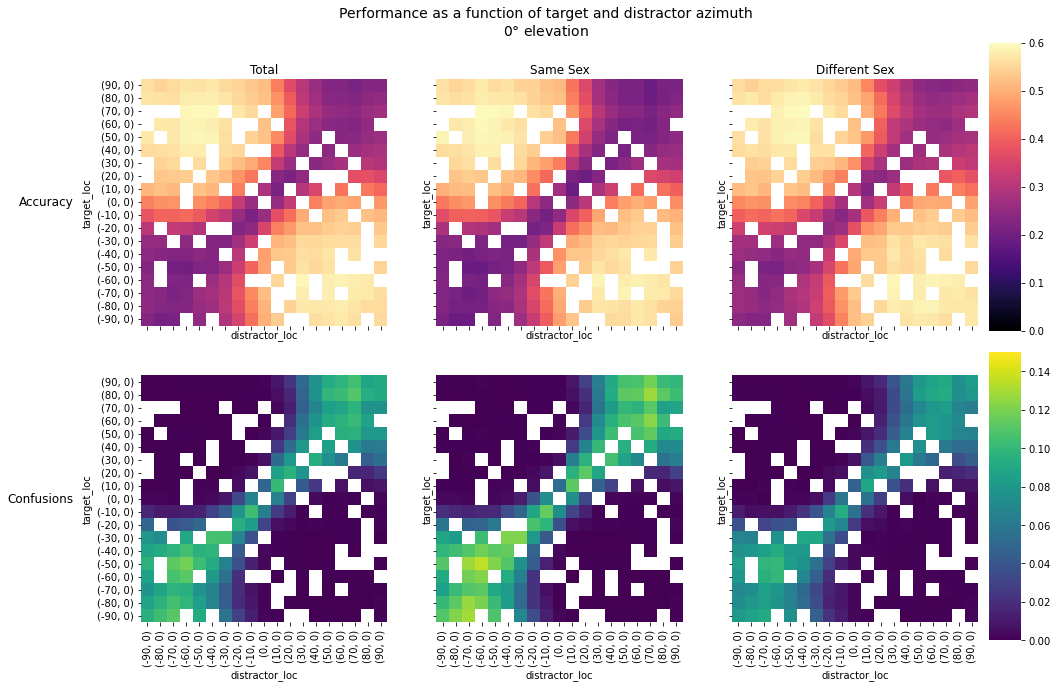

In [7]:
# plot all plots so far onto one figure
cols = ['Total', 'Same Sex', 'Different Sex']
rows = ['Accuracy', 'Confusions']
fig, axs = plt.subplots(2, 3, figsize=(15, 10), sharex=True, sharey=True)
cbar_ax_1 = fig.add_axes([.91, .53, .03, .4])
cbar_ax_2 = fig.add_axes([.91, .1, .03, .4])
total_acc = result_df.groupby(['target_loc', 'distractor_loc']).mean()['accuracy']
sns.heatmap(total_acc.unstack(), vmin=0, vmax=.6, cmap='magma', cbar=True, cbar_ax=cbar_ax_1, ax=axs[0, 0])
total_con = result_df.groupby(['target_loc', 'distractor_loc']).mean()['confusions']
sns.heatmap(total_con.unstack(), vmin=0, vmax=0.15, cmap='viridis', cbar=True, cbar_ax=cbar_ax_2, ax=axs[1, 0])
same_sex_acc = same_sex.groupby(['target_loc', 'distractor_loc']).mean()['accuracy']
sns.heatmap(same_sex_acc.unstack(), vmin=0, vmax=.6, cmap='magma', cbar=False, cbar_ax=None, ax=axs[0, 1])
same_sex_con = same_sex.groupby(['target_loc', 'distractor_loc']).mean()['confusions']
sns.heatmap(same_sex_con.unstack(), vmin=0, vmax=0.15, cmap='viridis', cbar=False, cbar_ax=None, ax=axs[1, 1])
diff_sex_acc = diff_sex.groupby(['target_loc', 'distractor_loc']).mean()['accuracy']
sns.heatmap(diff_sex_acc.unstack(), vmin=0, vmax=.6, cmap='magma', cbar=False, cbar_ax=None, ax=axs[0, 2])
diff_sex_con = diff_sex.groupby(['target_loc', 'distractor_loc']).mean()['confusions']
sns.heatmap(diff_sex_con.unstack(), vmin=0, vmax=0.15, cmap='viridis', cbar=False, cbar_ax=None, ax=axs[1, 2])
for ax, col in zip(axs[0], cols):
    ax.annotate(col, xy=(0.5, 1), xytext=(0, 5), size='large', ha='center', va='baseline', xycoords='axes fraction', textcoords='offset points')
for ax, row in zip(axs[:, 0], rows):
    ax.annotate(row, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0), xycoords=ax.yaxis.label, textcoords='offset points', size='large', ha='right', va='center')
# fig.tight_layout(rect=[0,0,.9,1])

plt.suptitle('Performance as a function of target and distractor azimuth\n$0\degree$ elevation', fontsize=14, y=0.98);

np.vectorize(lambda ax: ax.invert_yaxis())(axs);

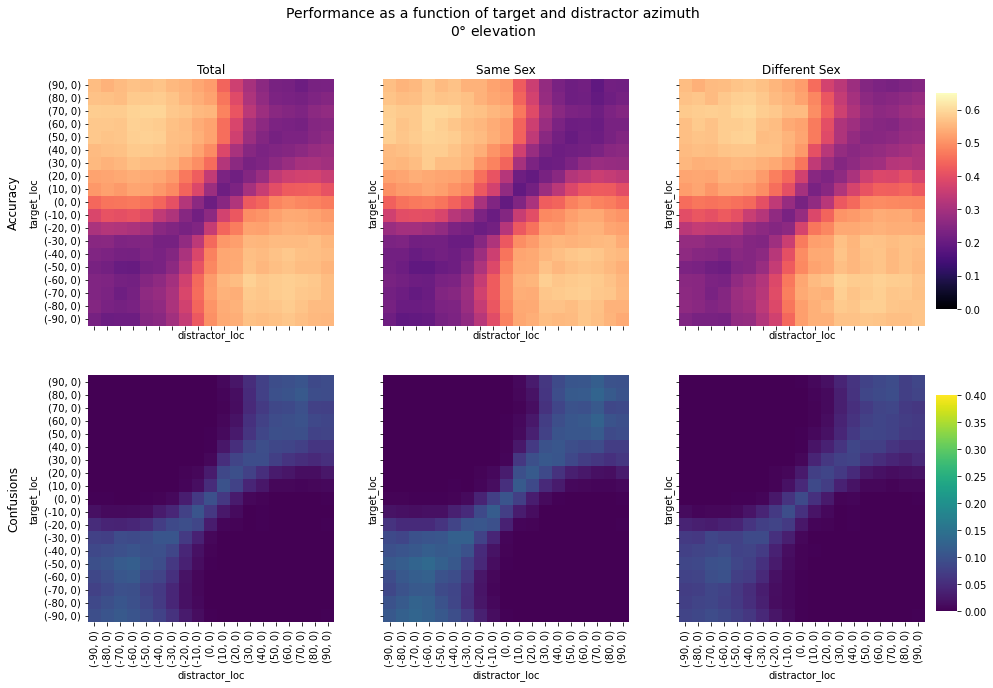

In [42]:
# plot all plots so far onto one figure
cols = ['Total', 'Same Sex', 'Different Sex']
rows = ['Accuracy', 'Confusions']

fig, axs = plt.subplots(2, 3, figsize=(15, 10), sharex=True, sharey=True)

cbar_ax_1 = fig.add_axes([.91, .56, .02, .3])
cbar_ax_2 = fig.add_axes([.91, .14, .02, .3])

total_acc = result_df.groupby(["target_loc", "distractor_loc"]).mean()['accuracy']
sns.heatmap(total_acc.unstack(), vmin=0, vmax=.65, cmap='magma', cbar=True, cbar_ax=cbar_ax_1, ax=axs[0, 0])
total_con = result_df.groupby(["target_loc", "distractor_loc"]).mean()['confusions']
sns.heatmap(total_con.unstack(), vmin=0, vmax=0.4, cmap='viridis', cbar=True, cbar_ax=cbar_ax_2, ax=axs[1, 0])

same_sex_acc = same_sex.groupby(["target_loc", "distractor_loc"])['accuracy'].mean()
sns.heatmap(same_sex_acc.unstack(), vmin=0, vmax= .65, cmap='magma', cbar=False, cbar_ax=None, ax=axs[0, 1])
same_sex_con = same_sex.groupby(["target_loc", "distractor_loc"])['confusions'].mean()
sns.heatmap(same_sex_con.unstack(), vmin=0, vmax=0.4, cmap='viridis', cbar=False, cbar_ax=None, ax=axs[1, 1])

diff_sex_acc = diff_sex.groupby(["target_loc", "distractor_loc"])['accuracy'].mean()
sns.heatmap(diff_sex_acc.unstack(), vmin=0, vmax=.65, cmap='magma', cbar=False, cbar_ax=None, ax=axs[0, 2])
diff_sex_con = diff_sex.groupby(["target_loc", "distractor_loc"])['confusions'].mean()
sns.heatmap(diff_sex_con.unstack(), vmin=0, vmax=0.4, cmap='viridis', cbar=False, cbar_ax=None, ax=axs[1, 2])

for ax, col in zip(axs[0], cols):
    ax.annotate(col, xy=(0.5, 1), xytext=(0, 5), size='large', ha='center', va='baseline', xycoords='axes fraction', textcoords='offset points',)
for ax, row in zip(axs[:, 0], rows):
    ax.annotate(row, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0), xycoords=ax.yaxis.label, textcoords='offset points', size='large', ha='right', va='center', rotation=90)

# fig.tight_layout(rect=[0,0,.9,1])
plt.suptitle('Performance as a function of target and distractor azimuth\n$0\degree$ elevation', fontsize=14, y=0.98);

np.vectorize(lambda ax: ax.invert_yaxis())(axs);

TypeError: 'AxesSubplot' object is not iterable

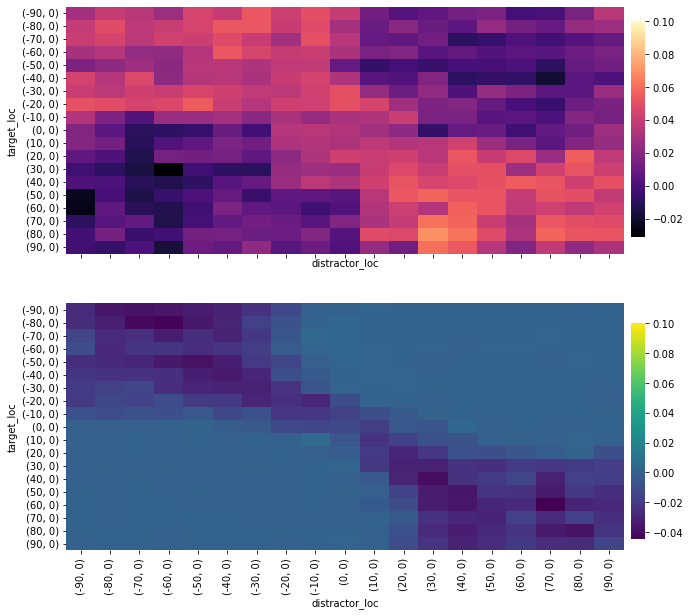

In [49]:
# plot all plots so far onto one figure
cols = ['Total', 'Same Sex', 'Different Sex']
rows = ['Accuracy', 'Confusions']

fig, axs = plt.subplots(2, 1, figsize=(10, 10), sharex=True, sharey=True)

cbar_ax_1 = fig.add_axes([.91, .56, .02, .3])
cbar_ax_2 = fig.add_axes([.91, .14, .02, .3])

diff = diff_sex.groupby(["target_loc", "distractor_loc"])['accuracy'].mean() - same_sex.groupby(["target_loc", "distractor_loc"])['accuracy'].mean()
sns.heatmap(diff.unstack(), vmax=0.1, cmap='magma', cbar=True, cbar_ax=cbar_ax_1, ax=axs[0])
diff = diff_sex.groupby(["target_loc", "distractor_loc"])['confusions'].mean() - same_sex.groupby(["target_loc", "distractor_loc"])['confusions'].mean()
sns.heatmap(diff.unstack(), vmax=0.1, cmap='viridis', cbar=True, cbar_ax=cbar_ax_2, ax=axs[1])

for ax, col in zip(axs[0], cols):
    ax.annotate(col, xy=(0.5, 1), xytext=(0, 5), size='large', ha='center', va='baseline', xycoords='axes fraction', textcoords='offset points',)
for ax, row in zip(axs[1], rows):
    ax.annotate(row, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0), xycoords=ax.yaxis.label, textcoords='offset points', size='large', ha='right', va='center', rotation=90)

# fig.tight_layout(rect=[0,0,.9,1])
plt.suptitle('Performance as a function of target and distractor azimuth\n$0\degree$ elevation', fontsize=14, y=0.98);

np.vectorize(lambda ax: ax.invert_yaxis())(axs);